In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение функций fft, fftfreq
from scipy.fft import fft, fftfreq

# подключение библиотеки
import matplotlib.pyplot as plt

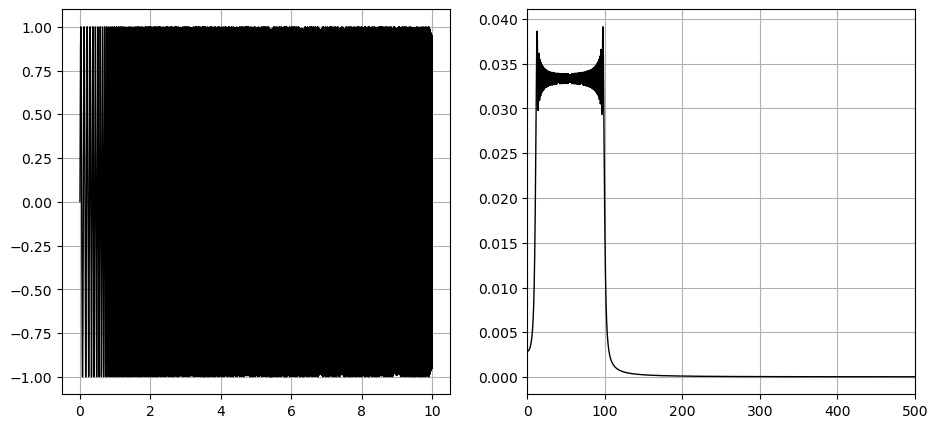

In [ ]:
# Ячейка № 2

# задание минимальной частоты
# ЛЧМ-сигнала
F0 = 10

# задание максимальной частоты
# ЛЧМ-сигнала
F1 = 100

# задание частоты дискретизации
Fd = 1000

# вычисление периода дискретизации
Td = 1 / Fd

# задание длительности
# временного интервала
Ts = 10

# вычисление числа отсчетов ДС
Np = round(Ts * Fd)

# создание массива, содержащего
# номера отсчетов ДС
i = np.arange(0, Np, 1)

# вычисление значения
# безразмерной частоты F0
f0 = F0 / Fd

# вычисление значения
# безразмерной частоты F0
f1 = F1 / Fd

# вычисление значений ДС
x = np.sin(2 * np.pi * (f0 * i + (f1 - f0) / (2 * (Ts * Fd)) * i**2))

# вычисление координат узлов ВС
t = Td * i

# вычисление и визуализация
# коэффициентов ДПФ

# определяем шаг временной сетки,
# в узлах которой вычислены значения
# анализируемого cигнала
dt = t[1] - t[0]

# вычисляем значения комплекснозначных
# коэффициентов ряда Фурье
c = fft(x)

# вычисляем соответствующие значения
# частот спектральных гармоник
Freq = fftfreq(Np, dt)


# визуализация информативной части спектра

# задание числа информативных спектральных гармоник
N2 = round(Np / 2) - 1

# инициализация массивов, используемых для хранения
# значений частот информативных спектральных гармоник
# и соответствующих нормированных амплитуд
c_R = np.zeros(N2)
Freq_R = np.zeros(N2)

# размещение в массивах Freq_R и c_R
# значений частот информативных спектральных гармоник
# и соответствующих нормированных амплитуд
for i in range(N2):
    Freq_R[i] = Freq[i + 1]
    c_R[i] = np.abs(c[i + 1]) / Np

fig = plt.figure(figsize=(11, 5))

# визуализация АС, ДС и
# восстановленного АС (слева)
ax = fig.add_subplot(121)
plt.plot(t, x, "-k", lw=1)
plt.grid(True)

ax = fig.add_subplot(122)
plt.plot(Freq_R, 2 * c_R, "-k", lw=1)
plt.xlim([0, Fd / 2])
plt.grid(True)

plt.show()


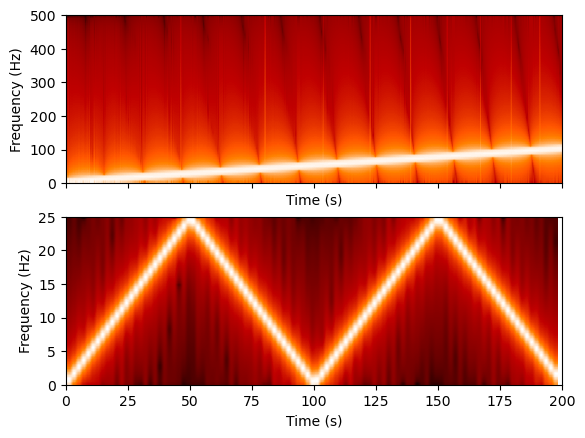

In [ ]:
# Ячейка № 2

# задание минимальной частоты
# ЛЧМ-сигнала
F0 = 0

# задание максимальной частоты
# ЛЧМ-сигнала
F1 = 100

# задание частоты дискретизации
Fd1 = 500

# вычисление периода дискретизации
Td = 1 / Fd

# задание длительности
# временного интервала
Ts = 200

# вычисление числа отсчетов ДС
Np = round(Ts * Fd)

# создание массива, содержащего
# номера отсчетов ДС
i = np.arange(0, Np, 1)

# вычисление значения
# безразмерной частоты F0
f0 = F0 / Fd

# вычисление значения
# безразмерной частоты F0
f1 = F1 / Fd

# вычисление значений ДС
x = np.sin(2 * np.pi * (f0 * i + (f1 - f0) / (2 * (Ts * Fd)) * i**2))

# задание минимальной частоты
# ЛЧМ-сигнала
F0 = 0

# задание максимальной частоты
# ЛЧМ-сигнала
F1 = 100

# задание частоты дискретизации
Fd2 = 50

# вычисление периода дискретизации
Td2 = 1 / Fd2

# задание длительности
# временного интервала
Ts = 200

# вычисление числа отсчетов ДС
Np2 = round(Ts * Fd2)

# создание массива, содержащего
# номера отсчетов ДС
i2 = np.arange(0, Np2, 1)

# вычисление значения
# безразмерной частоты F0
f0 = F0 / Fd2

# вычисление значения
# безразмерной частоты F0
f1 = F1 / Fd2

# вычисление значений ДС
x2 = np.sin(2 * np.pi * (f0 * i2 + (f1 - f0) / (2 * (Ts * Fd2)) * i2**2))

fig, (ax1, ax2) = plt.subplots(nrows=2, sharex=True)
Pxx, freqs, bins, im = ax1.specgram(
    x, NFFT=128, Fs=Fd, noverlap=32, cmap=plt.cm.gist_heat
)
# The `specgram` method returns 4 objects. They are:
# - Pxx: the periodogram
# - freqs: the frequency vector
# - bins: the centers of the time bins
# - im: the .image.AxesImage instance representing the data in the plot
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Frequency (Hz)")
ax1.set_xlim(0, Ts)

Pxx, freqs, bins, im = ax2.specgram(
    x2, NFFT=128, Fs=Fd2, noverlap=32, cmap=plt.cm.gist_heat
)
# The `specgram` method returns 4 objects. They are:
# - Pxx: the periodogram
# - freqs: the frequency vector
# - bins: the centers of the time bins
# - im: the .image.AxesImage instance representing the data in the plot
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Frequency (Hz)")
ax2.set_xlim(0, Ts)

plt.show()